In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(42)

# --- Cluster parameters ---
# A and B are close together; C is farther away
center_A = np.array([0.0, 0.0])
center_B = np.array([3.5, 0.5])   # close to A
center_C = np.array([1.5, 5.5])   # well separated from A and B
std = 1.2


In [11]:
# 350 samples each for A and B, 300 for C (total = 1000)
n_A, n_B, n_C = 350, 350, 300

data_A = rng.normal(center_A, std, size=(n_A, 2))
data_B = rng.normal(center_B, std, size=(n_B, 2))
data_C = rng.normal(center_C, std, size=(n_C, 2))

# Split C into 3 equal blocks of 100
c_blocks = np.array_split(data_C, 3)

# --- Build 4 A/B segments with runs of 5-10 consecutive samples before switching ---
seg_specs = [
    ('A', 88, 87),
    ('B', 87, 88),
    ('A', 88, 87),
    ('B', 87, 88),
]

a_ptr = b_ptr = 0
ab_segments = []

for start, na, nb in seg_specs:
    a_chunk = data_A[a_ptr : a_ptr + na];  a_ptr += na
    b_chunk = data_B[b_ptr : b_ptr + nb];  b_ptr += nb

    seg_data, seg_labels = [], []
    ai = bi = 0
    current = start  # which cluster is active

    while ai < na or bi < nb:
        run_len = int(rng.integers(5, 11))  # 5 to 10 inclusive
        if current == 'A':
            take = min(run_len, na - ai)
            seg_data.extend(a_chunk[ai : ai + take])
            seg_labels.extend(['A'] * take)
            ai += take
            current = 'B'
        else:
            take = min(run_len, nb - bi)
            seg_data.extend(b_chunk[bi : bi + take])
            seg_labels.extend(['B'] * take)
            bi += take
            current = 'A'

    ab_segments.append((np.array(seg_data), seg_labels))

# --- Assemble full sequence ---
# Layout: AB_seg | C_block | AB_seg | C_block | AB_seg | C_block | AB_seg
all_data, all_labels = [], []

for i, (seg_data, seg_labels) in enumerate(ab_segments):
    all_data.append(seg_data)
    all_labels.extend(seg_labels)
    if i < 3:                        # insert a C block after each of the first 3 AB segments
        all_data.append(c_blocks[i])
        all_labels.extend(['C'] * len(c_blocks[i]))

data = np.vstack(all_data)
labels = np.array(all_labels)

# --- Package as a DataFrame ---
df = pd.DataFrame(data, columns=['feature_1', 'feature_2'])
df['cluster'] = labels
df.index.name = 'time'

print("Cluster counts:\n", df['cluster'].value_counts().sort_index())
print(f"\nTotal observations: {len(df)}")

# Show where the C blocks appear
c_positions = np.where(labels == 'C')[0]
gaps = np.where(np.diff(c_positions) > 1)[0]
c_starts = [c_positions[0]] + list(c_positions[gaps + 1])
c_ends   = list(c_positions[gaps]) + [c_positions[-1]]
print("\nC-block time ranges:")
for s, e in zip(c_starts, c_ends):
    print(f"  t = {s} – {e}  ({e - s + 1} observations)")


Cluster counts:
 cluster
A    350
B    350
C    300
Name: count, dtype: int64

Total observations: 1000

C-block time ranges:
  t = 175 – 274  (100 observations)
  t = 450 – 549  (100 observations)
  t = 725 – 824  (100 observations)


In [12]:
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

# Fit k-means (k=3) on the feature data
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km_labels_int = km.fit_predict(data)   # integer labels 0/1/2, arbitrary order

# Match k-means centroids to true cluster centers A/B/C via the Hungarian algorithm
# so we can assign consistent letter labels
true_centers = np.array([center_A, center_B, center_C])  # rows: A=0, B=1, C=2
km_centers   = km.cluster_centers_                        # rows: km cluster 0/1/2

# Cost matrix: Euclidean distance between each true center and each k-means centroid
cost = np.linalg.norm(true_centers[:, None, :] - km_centers[None, :, :], axis=2)
true_order, km_order = linear_sum_assignment(cost)
# km_order[i] is the k-means cluster that best matches true cluster true_order[i]

km_to_letter = {}
for t_idx, k_idx in zip(true_order, km_order):
    km_to_letter[k_idx] = ['A', 'B', 'C'][t_idx]

labels = np.array([km_to_letter[l] for l in km_labels_int])
df['cluster'] = labels


print("K-means cluster counts:")
print(df['cluster'].value_counts().sort_index())



K-means cluster counts:
cluster
A    344
B    353
C    303
Name: count, dtype: int64


c:\Users\tmlouw\AppData\Local\miniconda3\envs\py3_13\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


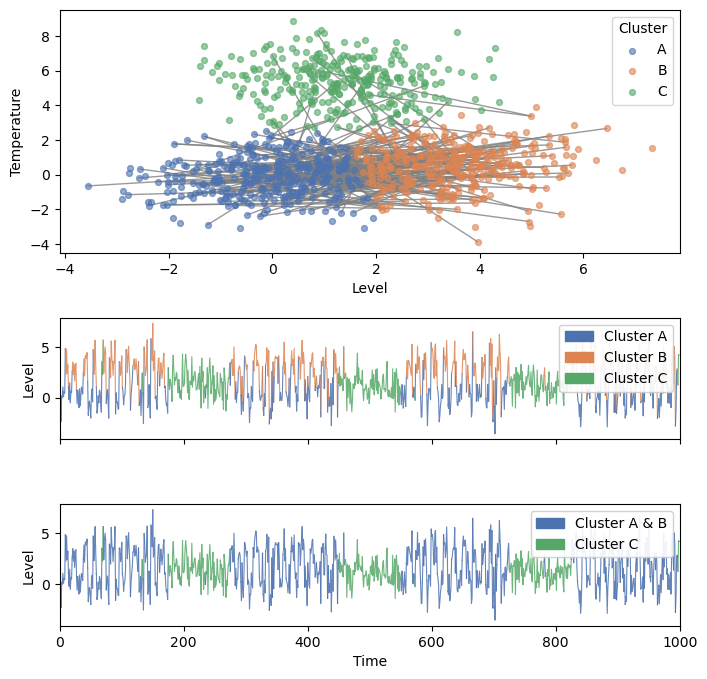

In [13]:
colors     = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}
colors_bin = {'A': '#4C72B0', 'B': '#4C72B0', 'C': '#55A868'}  # A and B both blue

cluster_int  = df['cluster'].map({'A': 0, 'B': 1, 'C': 2}).values
switch_indices = np.where(np.diff(cluster_int) != 0)[0]

# Contiguous runs for time-series colouring
run_starts_list = [0]
run_labels_list = [labels[0]]
for idx in range(1, len(labels)):
    if labels[idx] != labels[idx - 1]:
        run_starts_list.append(idx)
        run_labels_list.append(labels[idx])
run_starts_list.append(len(labels))

# --- Layout: scatter on top, two time-series panels below ---
fig = plt.figure(figsize=(8, 8))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4)

ax_scatter = fig.add_subplot(gs[0])
ax_ts      = fig.add_subplot(gs[1])
ax_ts2     = fig.add_subplot(gs[2], sharex=ax_ts)

# ── Scatter plot ──────────────────────────────────────────────
for i in switch_indices:
    ax_scatter.plot([df['feature_1'].iloc[i], df['feature_1'].iloc[i + 1]],
                    [df['feature_2'].iloc[i], df['feature_2'].iloc[i + 1]],
                    color='grey', linewidth=1, alpha=0.8, zorder=1)

for label, grp in df.groupby('cluster'):
    ax_scatter.scatter(grp['feature_1'], grp['feature_2'],
                       s=18, alpha=0.6, color=colors[label], label=label, zorder=2)

ax_scatter.set_xlabel('Level')
ax_scatter.set_ylabel('Temperature')
ax_scatter.legend(title='Cluster')

# ── Time-series panel 1: A, B, C in distinct colours ─────────
for k in range(len(run_labels_list)):
    start = run_starts_list[k]
    end   = run_starts_list[k + 1]
    sl = slice(start, min(end + 1, len(df)))
    ax_ts.plot(df.index[sl], df['feature_1'].iloc[sl],
               color=colors[run_labels_list[k]], linewidth=0.8, alpha=0.85)

ax_ts.set_ylabel('Level')
ax_ts.tick_params(labelbottom=False)
legend_patches = [mpatches.Patch(color=colors[k], label=f'Cluster {k}') for k in 'ABC']
ax_ts.legend(handles=legend_patches, loc='upper right', framealpha=0.9)

# ── Time-series panel 2: A and B both blue, C green ──────────
for k in range(len(run_labels_list)):
    start = run_starts_list[k]
    end   = run_starts_list[k + 1]
    sl = slice(start, min(end + 1, len(df)))
    ax_ts2.plot(df.index[sl], df['feature_1'].iloc[sl],
                color=colors_bin[run_labels_list[k]], linewidth=0.8, alpha=0.85)

ax_ts2.set_ylabel('Level')
ax_ts2.set_xlabel('Time')
ax_ts2.set_xlim(0, 1000)
legend_patches2 = [mpatches.Patch(color='#4C72B0', label='Cluster A & B'),
                   mpatches.Patch(color='#55A868', label='Cluster C')]
ax_ts2.legend(handles=legend_patches2, loc='upper right', framealpha=0.9)

plt.show()


In [14]:
df['next cluster'] = df['cluster'].shift(-1)
df_valid = df.dropna(subset=['next cluster'])
cm = confusion_matrix(df_valid['cluster'], df_valid['next cluster'], labels=['A', 'B', 'C'])
cm

array([[260,  76,   8],
       [ 76, 269,   7],
       [  7,   8, 288]])

In [ ]:
# --- Merge A and B into D ---
df['label_bin'] = df['cluster'].map({'A': 'D', 'B': 'D', 'C': 'C'})

X = df[['feature_1', 'feature_2']].values
y = (df['label_bin'] == 'C').astype(int)   # 1 = C, 0 = D
clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                    random_state=42, eval_metric='logloss')
clf.fit(X, y)


              precision    recall  f1-score   support

     D (A+B)       1.00      0.99      1.00       139
           C       0.98      1.00      0.99        61

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



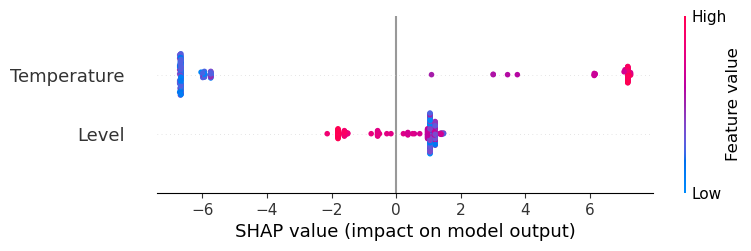

In [16]:
# --- SHAP analysis ---

explainer   = shap.TreeExplainer(clf)
shap_values = explainer(X_test)
shap_values.feature_names = ['Level', 'Temperature']
shap.plots.beeswarm(shap_values, show=False)

plt.show()
